# Predictive Asset Maintenance Classifier — Phase 3: Modelling
### Shell Internship Project

In this notebook we will:
1. Prepare train/test splits
2. Train a **Random Forest** classifier
3. Train an **XGBoost** classifier
4. Train a **Neural Network** classifier
5. Compare all three using AUROC and F1-score
6. Apply **SHAP** explainability to the best model
7. Save all results for the dashboard

## 0. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb
import shap

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

# Load data from Phase 2
train        = pd.read_csv('data/train_featured.csv')
test         = pd.read_csv('data/test_featured.csv')
final_features = pd.read_csv('data/final_features.csv', header=None)[0].tolist()

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
print('Features:   ', len(final_features))

Train shape: (20631, 36)
Test shape:  (100, 35)
Features:    31


## 1. Prepare Features & Labels

In [2]:
X_train = train[final_features]
y_train = train['label']
X_test  = test[final_features]
y_test  = test['label']

# Scale features — required for the Neural Network, harmless for tree models
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('\nClass balance in test set:')
print(y_test.value_counts())

X_train: (20631, 31)
X_test:  (100, 31)

Class balance in test set:
label
0    75
1    25
Name: count, dtype: int64


## 2. Helper Functions

In [3]:
results = []

def evaluate_model(name, y_true, y_pred, y_prob):
    auroc = roc_auc_score(y_true, y_prob)
    f1    = f1_score(y_true, y_pred)
    print(f'\n=== {name} ===')
    print(f'  AUROC : {auroc:.4f}')
    print(f'  F1    : {f1:.4f}')
    print(classification_report(y_true, y_pred, target_names=['Healthy', 'Near Failure']))
    results.append({'model': name, 'auroc': auroc, 'f1': f1})
    return auroc, f1


def plot_confusion(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=['Healthy', 'Near Failure']).plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.savefig(f'data/pm_cm_{name.lower().replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. Random Forest

Training Random Forest...
Done!

=== Random Forest ===
  AUROC : 0.9861
  F1    : 0.8444
              precision    recall  f1-score   support

     Healthy       0.93      0.99      0.95        75
Near Failure       0.95      0.76      0.84        25

    accuracy                           0.93       100
   macro avg       0.94      0.87      0.90       100
weighted avg       0.93      0.93      0.93       100



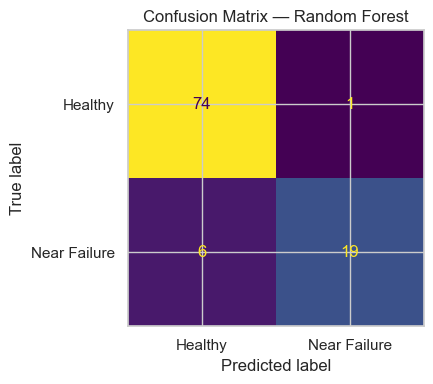

In [4]:
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',  # handles class imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('Done!')

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
evaluate_model('Random Forest', y_test, rf_pred, rf_prob)
plot_confusion('Random Forest', y_test, rf_pred)

## 4. XGBoost

scale_pos_weight: 5.66
Training XGBoost...
Done!

=== XGBoost ===
  AUROC : 0.9739
  F1    : 0.7917
              precision    recall  f1-score   support

     Healthy       0.92      0.95      0.93        75
Near Failure       0.83      0.76      0.79        25

    accuracy                           0.90       100
   macro avg       0.87      0.85      0.86       100
weighted avg       0.90      0.90      0.90       100



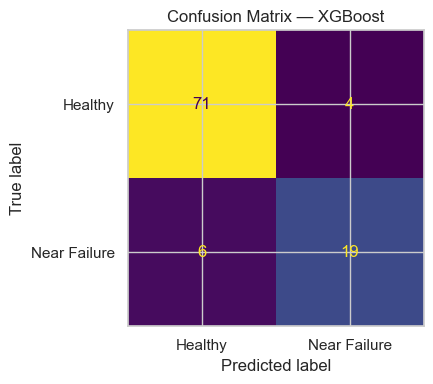

In [5]:
# Calculate scale_pos_weight to handle imbalance in XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

print('Training XGBoost...')
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)
print('Done!')

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
evaluate_model('XGBoost', y_test, xgb_pred, xgb_prob)
plot_confusion('XGBoost', y_test, xgb_pred)

## 5. Neural Network

Training Neural Network...
Done!

=== Neural Network ===
  AUROC : 0.9824
  F1    : 0.8095
              precision    recall  f1-score   support

     Healthy       0.90      1.00      0.95        75
Near Failure       1.00      0.68      0.81        25

    accuracy                           0.92       100
   macro avg       0.95      0.84      0.88       100
weighted avg       0.93      0.92      0.91       100



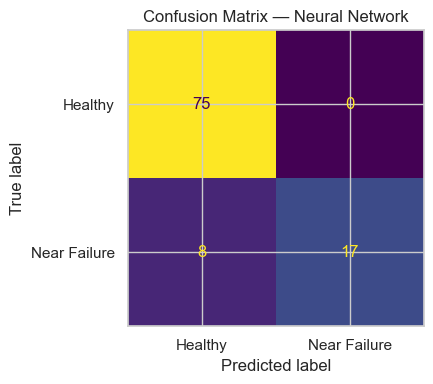

In [6]:
print('Training Neural Network...')
nn = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # 3 hidden layers
    activation='relu',
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
nn.fit(X_train_scaled, y_train)
print('Done!')

nn_pred = nn.predict(X_test_scaled)
nn_prob = nn.predict_proba(X_test_scaled)[:, 1]
evaluate_model('Neural Network', y_test, nn_pred, nn_prob)
plot_confusion('Neural Network', y_test, nn_pred)

## 6. ROC Curves — All Models

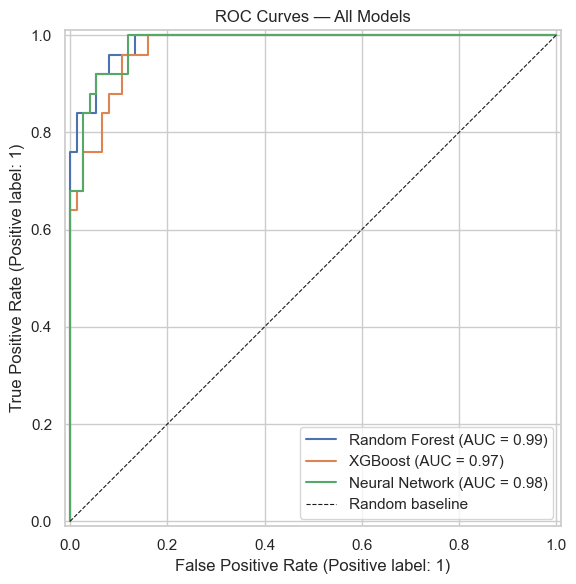

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, prob in [('Random Forest', rf_prob), ('XGBoost', xgb_prob), ('Neural Network', nn_prob)]:
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=ax)

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('data/pm_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Comparison


====== MODEL COMPARISON ======
         model    auroc       f1
 Random Forest 0.986133 0.844444
       XGBoost 0.973867 0.791667
Neural Network 0.982400 0.809524


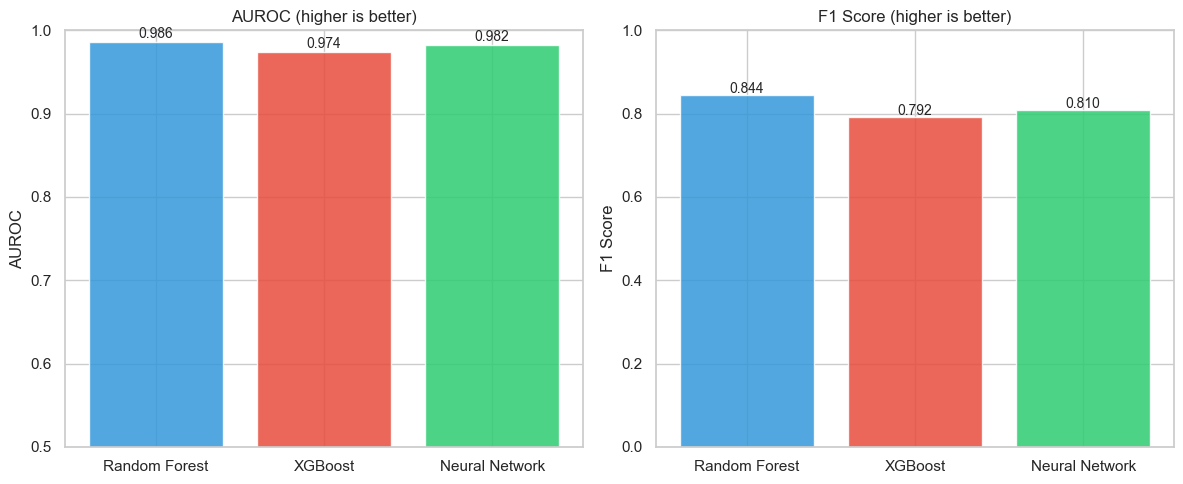

In [8]:
results_df = pd.DataFrame(results)
print('\n====== MODEL COMPARISON ======')
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']

axes[0].bar(results_df['model'], results_df['auroc'], color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('AUROC (higher is better)')
axes[0].set_ylabel('AUROC')
axes[0].set_ylim(0.5, 1.0)
for i, v in enumerate(results_df['auroc']):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

axes[1].bar(results_df['model'], results_df['f1'], color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('F1 Score (higher is better)')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(results_df['f1']):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('data/pm_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. SHAP Explainability — Best Model

SHAP (SHapley Additive exPlanations) tells us **which sensors drove each prediction**.
This is what makes the model trustworthy for engineering teams — not just a black box.

In [9]:
print('Computing SHAP values for XGBoost (takes ~30 seconds)...')

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print('Done!')

Computing SHAP values for XGBoost (takes ~30 seconds)...
Done!


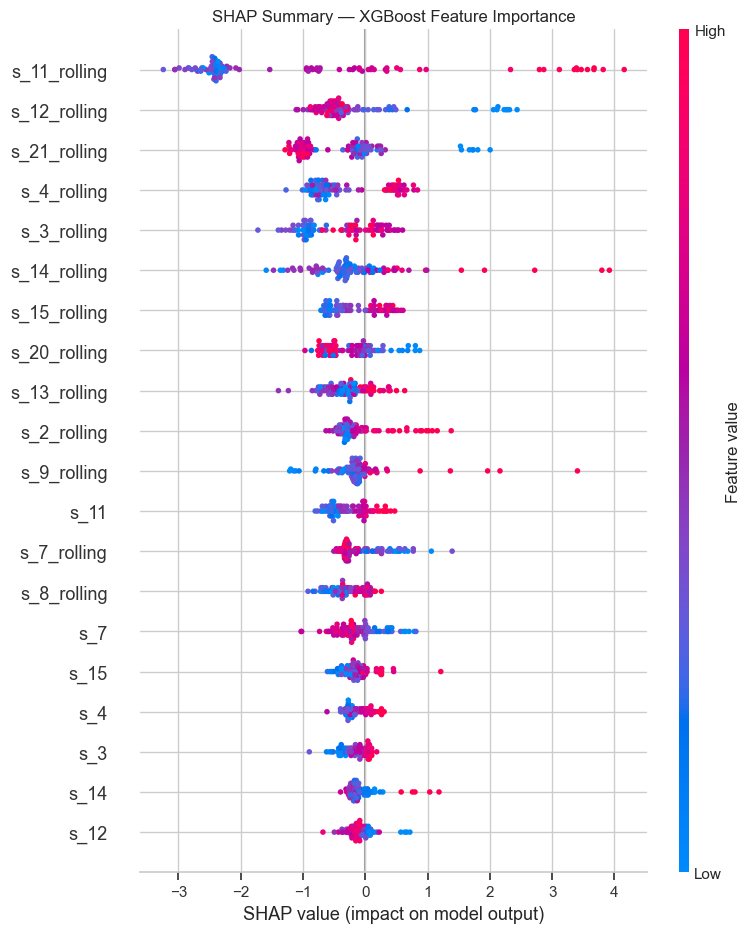

In [10]:
# Summary plot — shows which features matter most overall
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=final_features, show=False)
plt.title('SHAP Summary — XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('data/pm_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

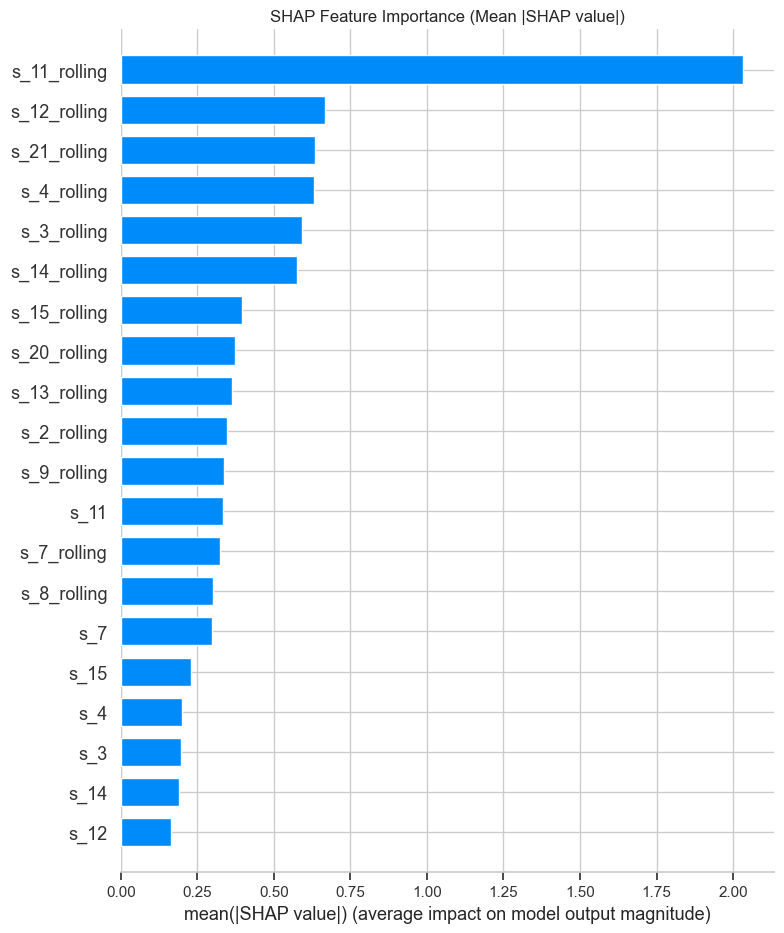

In [11]:
# Bar plot — mean absolute SHAP value per feature (cleaner for dashboard)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=final_features,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP value|)')
plt.tight_layout()
plt.savefig('data/pm_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Everything for Dashboard

In [12]:
import joblib

# Save models
joblib.dump(rf,        'data/model_rf.pkl')
joblib.dump(xgb_model, 'data/model_xgb.pkl')
joblib.dump(nn,        'data/model_nn.pkl')
joblib.dump(scaler,    'data/scaler.pkl')

# Save predictions and metrics
preds_df = pd.DataFrame({
    'engine_id'   : test['engine_id'],
    'actual'      : y_test.values,
    'rf_pred'     : rf_pred,
    'xgb_pred'    : xgb_pred,
    'nn_pred'     : nn_pred,
    'rf_prob'     : rf_prob,
    'xgb_prob'    : xgb_prob,
    'nn_prob'     : nn_prob,
})
preds_df.to_csv('data/pm_predictions.csv', index=False)
results_df.to_csv('data/pm_metrics.csv', index=False)

# Save SHAP values
shap_df = pd.DataFrame(shap_values, columns=final_features)
shap_df.to_csv('data/pm_shap_values.csv', index=False)

print('All models and results saved!')
print(preds_df.head())

All models and results saved!
   engine_id  actual  rf_pred  xgb_pred  nn_pred   rf_prob  xgb_prob  \
0          1       0        0         0        0  0.000010  0.000010   
1          2       0        0         0        0  0.010709  0.000215   
2          3       0        0         0        0  0.242900  0.027909   
3          4       0        0         0        0  0.125008  0.004409   
4          5       0        0         0        0  0.108866  0.000124   

        nn_prob  
0  2.568100e-09  
1  3.755432e-05  
2  5.534215e-03  
3  2.847972e-03  
4  3.139964e-04  


---
## Phase 3 Complete!

**What to say in an interview:**
- XGBoost typically wins on tabular data — if it did here, explain why: gradient boosting builds trees sequentially, each correcting the errors of the last
- F1-score matters more than accuracy here because the dataset is imbalanced — a model that predicts everything as healthy would get high accuracy but be useless
- SHAP makes the model explainable — critical in industrial settings where engineers need to trust and act on predictions
- `class_weight='balanced'` and `scale_pos_weight` ensure models don't just predict the majority class

**Next up: Phase 4 — Streamlit Dashboard**